In [ ]:
import os
import zipfile
from google.colab import drive
import numpy as np
import pandas as pd
# 1. Kết nối Google Drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# 1. Kết nối Google Drive
drive.mount('/content/drive')

# 2. Định nghĩa đường dẫn
ZIP_PATH = '/content/drive/MyDrive/Drowsiness_Project/regions_dataset.zip' # Đường dẫn tới file zip trên Drive của bạn
EXTRACT_DIR = '/content/data/regions'           # Giải nén trực tiếp vào ổ SSD của Colab

# 3. Giải nén dữ liệu
if not os.path.exists(EXTRACT_DIR):
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    print("⏳ Đang giải nén dữ liệu vào ổ cứng Colab...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall('/content/data')
    print("✅ Đã giải nén xong vào:", EXTRACT_DIR)
else:
    print("✅ Dữ liệu đã sẵn sàng tại:", EXTRACT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⏳ Đang giải nén dữ liệu vào ổ cứng Colab...
✅ Đã giải nén xong vào: /content/data/regions


In [ ]:
import os, torch, cv2, gc
import numpy as np
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split

SEQ_LEN      = 16
IMG_SIZE     = 224
BATCH        = 4
WORKERS      = 2
IMAGE_EXTS   = {'.jpg', '.jpeg', '.png', '.bmp'}
REGIONS_BASE = '/content/data/regions'  # Thư mục chứa regions đã giải nén

# ── Giữ nguyên Data Augmentation gốc ──
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussNoise(p=0.3),
    A.CoarseDropout(num_holes_range=(1,4), hole_height_range=(8,16), hole_width_range=(8,16), p=0.3),
    A.RandomGamma(p=0.3),
    A.RandomShadow(p=0.3),
    A.ImageCompression(quality_range=(50, 90), p=0.3),
    A.GaussianBlur(blur_limit=(3, 7), p=0.3),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=0.4),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# ── Hàm load 3 vùng Face / Eye / Mouth trực tiếp từ disk ──
def load_regions(face_path, transform):
    blank = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)

    def get_crop(p):
        if os.path.exists(p):
            try:
                return np.array(Image.open(p).convert('RGB'))
            except:
                pass
        return blank

    eye_path   = face_path.replace('/face/', '/eye/')
    mouth_path = face_path.replace('/face/', '/mouth/')

    def to_tensor(img):
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        return transform(image=img)['image']

    return to_tensor(get_crop(face_path)), to_tensor(get_crop(eye_path)), to_tensor(get_crop(mouth_path))


# ── Dataset Classes (Giữ nguyên cấu trúc trả về) ──
class VideoSequenceDataset(Dataset):
    def __init__(self, records, transform, stride=8):
        self.transform = transform
        self.sequences = []
        for r in records:
            frames = sorted([
                os.path.join(r['path'], f) for f in os.listdir(r['path'])
                if Path(f).suffix.lower() in IMAGE_EXTS
            ])
            if len(frames) < SEQ_LEN:
                continue
            for start in range(0, len(frames) - SEQ_LEN + 1, stride):
                self.sequences.append((frames[start:start + SEQ_LEN], r['label']))

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        frame_paths, label = self.sequences[idx]
        faces, eyes, mouths = [], [], []
        for p in frame_paths:
            f, e, m = load_regions(p, self.transform)
            faces.append(f)
            eyes.append(e)
            mouths.append(m)
        return (
            torch.stack(faces),
            torch.stack(eyes),
            torch.stack(mouths),
            torch.tensor(label, dtype=torch.long),
            True
        )

class ImageDataset(Dataset):
    def __init__(self, records, transform):
        self.records   = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]
        f, e, m = load_regions(r['path'], self.transform)
        return f, e, m, torch.tensor(r['label'], dtype=torch.long), False


# ── Quét danh sách Video từ thư mục regions/ ──
def collect_video_records(split):
    records = []
    # YawDD & DROZY
    for source in ['yawdd', 'drozy']:
        for cls, label in [('alert', 0), ('drowsy', 1)]:
            base = f'{REGIONS_BASE}/{source}/face/{split}/{cls}'
            if not os.path.exists(base):
                continue
            for vid in os.listdir(base):
                vid_path = os.path.join(base, vid)
                if os.path.isdir(vid_path):
                    records.append({'path': vid_path, 'label': label})

    # NITYMED
    base = f'{REGIONS_BASE}/nitymed/face/{split}/drowsy'
    if os.path.exists(base):
        for vid in os.listdir(base):
            vid_path = os.path.join(base, vid)
            if os.path.isdir(vid_path):
                records.append({'path': vid_path, 'label': 1})
    return records

# ── Quét danh sách Ảnh tĩnh từ thư mục regions/images/ ──
def collect_image_records():
    source_subsets = [
        ('mrl_open_train',  0, 'mrl'),
        ('mrl_close_train', 1, 'mrl'),
        ('mrl_open_test',   0, 'mrl'),
        ('mrl_close_test',  1, 'mrl'),
        ('nthu_notdrowsy',  0, 'nthu'),
        ('nthu_drowsy',     1, 'nthu'),
        ('cew_open',        0, 'cew'),
        ('cew_closed',      1, 'cew'),
    ]
    records = []
    for subset_name, label, source in source_subsets:
        folder = f'{REGIONS_BASE}/images/{subset_name}/face'
        if not os.path.exists(folder):
            print(f'⚠️ Missing: {folder}')
            continue
        for f in Path(folder).rglob('*'):
            if f.suffix.lower() in IMAGE_EXTS:
                records.append({'path': str(f), 'label': label, 'source': source})
    return records

def collate_fn(batch):
    faces, eyes, mouths, labels, is_seqs = zip(*batch)
    return list(faces), list(eyes), list(mouths), torch.stack(labels), list(is_seqs)

# ── Xây dựng tập Splits (Giữ nguyên random_state=42 và tỷ lệ) ──
train_vid = collect_video_records('train')
val_vid   = collect_video_records('val')
test_vid  = collect_video_records('test')

img_records = collect_image_records()
img_labels  = [r['label'] for r in img_records]
img_train, img_temp = train_test_split(img_records, test_size=0.30,
                                        stratify=img_labels, random_state=42)
img_val, img_test   = train_test_split(img_temp, test_size=0.50,
                                        stratify=[r['label'] for r in img_temp],
                                        random_state=42)

# ── Tạo DataLoader ──
train_ds = ConcatDataset([
    VideoSequenceDataset(train_vid, train_transform, stride=8),
    ImageDataset(img_train, train_transform)
])
val_ds = ConcatDataset([
    VideoSequenceDataset(val_vid, val_transform, stride=16),
    ImageDataset(img_val, val_transform)
])
test_ds = ConcatDataset([
    VideoSequenceDataset(test_vid, val_transform, stride=16),
    ImageDataset(img_test, val_transform)
])

del train_vid, val_vid, test_vid, img_train, img_val, img_test, img_records
gc.collect()

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=WORKERS, pin_memory=True, persistent_workers=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                          num_workers=WORKERS, pin_memory=True, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,
                          num_workers=WORKERS, pin_memory=True, collate_fn=collate_fn)

print(f'Train samples : {len(train_ds)}')
print(f'Val   samples : {len(val_ds)}')
print(f'Test  samples : {len(test_ds)}')
print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

Train samples : 37876
Val   samples : 7388
Test  samples : 7443
Train batches : 9469
Val   batches : 1847
Test  batches : 1861


In [ ]:
import torch
import torch.nn as nn
import timm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using: {device}')

class TemporalAttention(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden, hidden // 4),
            nn.Tanh(),
            nn.Linear(hidden // 4, 1)
        )

    def forward(self, x):
        weights = torch.softmax(self.attn(x), dim=1)
        return (x * weights).sum(dim=1)

class MultiRegionCNNTCN(nn.Module):
    def __init__(self, backbone='tf_efficientnet_lite2', hidden=256, num_classes=2, seq_len=16):
        super().__init__()
        self.seq_len = seq_len

        self.cnn_face  = timm.create_model(backbone, pretrained=True, num_classes=0)
        self.cnn_eye   = timm.create_model(backbone, pretrained=True, num_classes=0)
        self.cnn_mouth = timm.create_model(backbone, pretrained=True, num_classes=0)
        feat_dim = self.cnn_face.num_features

        self.region_attn = nn.Sequential(
            nn.Linear(feat_dim * 3, 3),
            nn.Softmax(dim=1)
        )

        self.fusion = nn.Sequential(
            nn.Linear(feat_dim * 3, hidden),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.tcn = nn.Sequential(
            nn.Conv1d(hidden, hidden, kernel_size=3, padding=1, dilation=1),
            nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(0.2),
            nn.Conv1d(hidden, hidden, kernel_size=3, padding=2, dilation=2),
            nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(0.2),
            nn.Conv1d(hidden, hidden, kernel_size=3, padding=4, dilation=4),
            nn.BatchNorm1d(hidden), nn.ReLU(),
        )

        self.temporal_attn = TemporalAttention(hidden)

        self.image_head = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.classifier = nn.Linear(hidden, num_classes)

    def extract_single_chunk(self, face, eye, mouth):
        f_feat = self.cnn_face(face)
        e_feat = self.cnn_eye(eye)
        m_feat = self.cnn_mouth(mouth)

        combined = torch.cat([f_feat, e_feat, m_feat], dim=1)
        weights  = self.region_attn(combined)
        weighted = torch.cat([
            f_feat * weights[:, 0:1],
            e_feat * weights[:, 1:2],
            m_feat * weights[:, 2:3],
        ], dim=1)
        return self.fusion(weighted)

    def extract_regions(self, face, eye, mouth, chunk_size=16):
        """Forward từng cụm nhỏ (chunk) qua CNN để không tràn VRAM"""
        total_frames = face.size(0)
        if total_frames <= chunk_size:
            return self.extract_single_chunk(face, eye, mouth)

        chunks = []
        for i in range(0, total_frames, chunk_size):
            f_c = face[i : i + chunk_size]
            e_c = eye[i : i + chunk_size]
            m_c = mouth[i : i + chunk_size]
            chunks.append(self.extract_single_chunk(f_c, e_c, m_c))
        return torch.cat(chunks, dim=0)

    def forward(self, face, eye, mouth, is_sequence=True):
        if is_sequence:
            B, T, C, H, W = face.shape
            feats = self.extract_regions(
                face.view(B * T, C, H, W),
                eye.view(B * T, C, H, W),
                mouth.view(B * T, C, H, W),
                chunk_size=16  # Giới hạn 16 frame/lượt forward CNN
            )
            feats = feats.view(B, T, -1).permute(0, 2, 1)
            feats = self.tcn(feats)
            feats = feats.permute(0, 2, 1)
            feats = self.temporal_attn(feats)
        else:
            feats = self.extract_regions(face, eye, mouth, chunk_size=16)
            feats = self.image_head(feats)

        return self.classifier(feats)

model = MultiRegionCNNTCN(seq_len=SEQ_LEN).to(device)
print(f'Params: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M')

Using: cuda


model.safetensors: reconstructing file:   0%|          |  0.00B / 24.6MB            

model.safetensors: downloading bytes:           |  0.00B            

Params: 16.1M


In [ ]:
import os, gc, torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
torch.cuda.empty_cache()
gc.collect()

SAVE_DIR = '/content/drive/MyDrive/Drowsiness_Project'
os.makedirs(SAVE_DIR, exist_ok=True)

criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
)

ACCUM_STEPS = 8   # BATCH=8 * ACCUM_STEPS=4 = 32 mẫu/update
EPOCHS      = 30
EARLY_STOP  = 4
SAVE_EVERY_STEPS = 1500  # Tự động lưu checkpoint mỗi 1.500 steps

scaler = torch.amp.GradScaler('cuda')

start_epoch  = 1
start_step   = 0
best_val_acc = 0.8542
no_improve   = 0

train_loss_history = []
train_acc_history  = []
val_loss_history   = []
val_acc_history    = []

# ── 1. Nạp khôi phục Checkpoint thông minh ──
MID_CKPT_PATH  = f'{SAVE_DIR}/mid_checkpoint.pth'
LAST_CKPT_PATH = f'{SAVE_DIR}/last_checkpoint1.pth'
BEST_PATH      = f'{SAVE_DIR}/best_model.pth'

if os.path.exists(MID_CKPT_PATH):
    print(f"🔄 Tìm thấy Checkpoint dở dang giữa epoch: {MID_CKPT_PATH}")
    ckpt = torch.load(MID_CKPT_PATH, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    scaler.load_state_dict(ckpt['scaler_state_dict'])
    start_epoch        = ckpt['epoch']
    start_step         = ckpt.get('step', 0)
    best_val_acc       = ckpt['best_val_acc']
    no_improve         = ckpt['no_improve']
    train_loss_history = ckpt['train_loss_history']
    train_acc_history  = ckpt['train_acc_history']
    val_loss_history   = ckpt['val_loss_history']
    val_acc_history    = ckpt['val_acc_history']
    print(f"✅ Khôi phục thành công! Tiếp tục từ Epoch {start_epoch:02d} | Step {start_step}/{len(train_loader)}")
elif os.path.exists(LAST_CKPT_PATH):
    print(f"🔄 Nạp checkpoint gần nhất: {LAST_CKPT_PATH}")
    ckpt = torch.load(LAST_CKPT_PATH, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    scaler.load_state_dict(ckpt['scaler_state_dict'])
    start_epoch        = ckpt['epoch'] + 1
    best_val_acc       = ckpt['best_val_acc']
    no_improve         = ckpt['no_improve']
    train_loss_history = ckpt['train_loss_history']
    train_acc_history  = ckpt['train_acc_history']
    val_loss_history   = ckpt['val_loss_history']
    val_acc_history    = ckpt['val_acc_history']
    print(f"✅ Khôi phục thành công! Tiếp tục từ Epoch {start_epoch:02d}")
elif os.path.exists(BEST_PATH):
    print(f"🔄 Nạp trọng số từ {BEST_PATH}...")
    state_dict = torch.load(BEST_PATH, map_location=device)
    model.load_state_dict(state_dict['model_state_dict'] if 'model_state_dict' in state_dict else state_dict)
    start_epoch = 3
    print(f"✅ Nạp trọng số thành công! Tiếp tục huấn luyện từ Epoch {start_epoch:02d}")


def run_epoch(loader, current_epoch, train=True, skip_steps=0):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    optimizer.zero_grad()

    phase = "Train" if train else "Val"

    for step, (faces, eyes, mouths, labels, is_seqs) in enumerate(loader):
        if train and step < skip_steps:
            continue

        labels  = labels.to(device, non_blocking=True)
        seq_idx = [i for i, s in enumerate(is_seqs) if s]
        img_idx = [i for i, s in enumerate(is_seqs) if not s]
        all_logits, all_lbls = [], []

        with torch.set_grad_enabled(train):
            with torch.amp.autocast('cuda'):
                if seq_idx:
                    f = torch.stack([faces[i]  for i in seq_idx]).to(device, non_blocking=True)
                    e = torch.stack([eyes[i]   for i in seq_idx]).to(device, non_blocking=True)
                    m = torch.stack([mouths[i] for i in seq_idx]).to(device, non_blocking=True)
                    all_logits.append(model(f, e, m, is_sequence=True))
                    all_lbls.append(labels[seq_idx])
                    del f, e, m

                if img_idx:
                    f = torch.stack([faces[i]  for i in img_idx]).to(device, non_blocking=True)
                    e = torch.stack([eyes[i]   for i in img_idx]).to(device, non_blocking=True)
                    m = torch.stack([mouths[i] for i in img_idx]).to(device, non_blocking=True)
                    all_logits.append(model(f, e, m, is_sequence=False))
                    all_lbls.append(labels[img_idx])
                    del f, e, m

                logits = torch.cat(all_logits)
                lbls   = torch.cat(all_lbls)
                loss   = criterion(logits, lbls) / (ACCUM_STEPS if train else 1)

        if train:
            scaler.scale(loss).backward()
            if (step + 1) % ACCUM_STEPS == 0 or (step + 1) == len(loader):
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

        total_loss += loss.item() * (ACCUM_STEPS if train else 1)
        correct    += (logits.argmax(1) == lbls).sum().item()
        total      += len(lbls)
        del logits, lbls, loss

        if step % 200 == 0:
            gc.collect()
            torch.cuda.empty_cache()

        # In tiến độ cho cả Train và Val
        if step % 500 == 0 or (step + 1) == len(loader):
            pct = (step + 1) / len(loader) * 100
            curr_steps = (step + 1 - skip_steps) if train else (step + 1)
            print(f'  [{phase}] {pct:5.1f}% [{step+1:5d}/{len(loader)}] loss: {total_loss/curr_steps:.4f} acc: {correct/total:.4f}')

        # Auto-Save checkpoint giữa chừng
        if train and (step + 1) % SAVE_EVERY_STEPS == 0:
            mid_ckpt = {
                'epoch': current_epoch,
                'step': step + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'scaler_state_dict': scaler.state_dict(),
                'best_val_acc': best_val_acc,
                'no_improve': no_improve,
                'train_loss_history': train_loss_history,
                'train_acc_history': train_acc_history,
                'val_loss_history': val_loss_history,
                'val_acc_history': val_acc_history,
            }
            torch.save(mid_ckpt, f'{SAVE_DIR}/mid_checkpoint.pth')
            print(f'  💾 [Auto-Save] Đã lưu snapshot tại Step {step+1}/{len(loader)}')

    return total_loss / (len(loader) - skip_steps), correct / total


# ── 2. Vòng lặp Huấn luyện chính ──
for epoch in range(start_epoch, EPOCHS + 1):
    print(f'\n{"═"*60}')
    print(f'  Epoch {epoch:02d}/{EPOCHS}  |  LR: {optimizer.param_groups[0]["lr"]:.2e}')
    print(f'{"═"*60}')

    # Nếu vừa resume giữa chừng từ start_step, chỉ skip ở epoch đầu tiên
    skip = start_step if epoch == start_epoch else 0
    train_loss, train_acc = run_epoch(train_loader, epoch, train=True, skip_steps=skip)
    start_step = 0  # Reset step cho các epoch sau

    gc.collect()
    torch.cuda.empty_cache()

    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)
    print(f'  ► Train | Loss: {train_loss:.4f}  Acc: {train_acc:.4f}')

    # ── VALIDATION VÀ LƯU SAU MỖI EPOCH ──
    print(f'  ► Val   | running...')
    val_loss, val_acc = run_epoch(val_loader, epoch, train=False)
    gc.collect()
    torch.cuda.empty_cache()

    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc)
    print(f'  ► Val   | Loss: {val_loss:.4f}  Acc: {val_acc:.4f}')

    scheduler.step(val_acc)
    print(f'  ► LR now → {optimizer.param_groups[0]["lr"]:.2e}')

    full_checkpoint = {
        'epoch': epoch,
        'step': 0,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'best_val_acc': best_val_acc,
        'no_improve': no_improve,
        'train_loss_history': train_loss_history,
        'train_acc_history': train_acc_history,
        'val_loss_history': val_loss_history,
        'val_acc_history': val_acc_history,
    }

    # Luôn lưu trạng thái cuối epoch
    torch.save(full_checkpoint, f'{SAVE_DIR}/last_checkpoint1.pth')

    # Xóa file checkpoint giữa chừng của epoch cũ vì epoch đã hoàn tất
    if os.path.exists(f'{SAVE_DIR}/mid_checkpoint.pth'):
        os.remove(f'{SAVE_DIR}/mid_checkpoint.pth')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        no_improve   = 0
        full_checkpoint['best_val_acc'] = best_val_acc
        full_checkpoint['no_improve']   = no_improve

        torch.save(model.state_dict(), f'{SAVE_DIR}/best_model.pth')
        torch.save(full_checkpoint, f'{SAVE_DIR}/best_checkpoint1.pth')
        print(f'  ✓ New best saved (val_acc={val_acc:.4f})')
    else:
        no_improve += 1
        print(f'  ✗ No improvement ({no_improve}/{EARLY_STOP})')
        if no_improve >= EARLY_STOP:
            print(f'  ⚠ Early stopping triggered.')
            break

print(f'\n{"═"*60}')
print(f'  Training complete.  Best val_acc: {best_val_acc:.4f}')
print(f'{"═"*60}')

🔄 Nạp checkpoint gần nhất: /content/drive/MyDrive/Drowsiness_Project/last_checkpoint1.pth
✅ Khôi phục thành công! Tiếp tục từ Epoch 23

════════════════════════════════════════════════════════════
  Epoch 23/30  |  LR: 5.00e-05
════════════════════════════════════════════════════════════
  [Train]   0.0% [    1/9469] loss: 0.0852 acc: 1.0000
  [Train]   5.3% [  501/9469] loss: 0.0599 acc: 0.9770
  [Train]  10.6% [ 1001/9469] loss: 0.0603 acc: 0.9758
  💾 [Auto-Save] Đã lưu snapshot tại Step 1500/9469
  [Train]  15.9% [ 1501/9469] loss: 0.0591 acc: 0.9758
  [Train]  21.1% [ 2001/9469] loss: 0.0592 acc: 0.9770
  [Train]  26.4% [ 2501/9469] loss: 0.0569 acc: 0.9779
  💾 [Auto-Save] Đã lưu snapshot tại Step 3000/9469
  [Train]  31.7% [ 3001/9469] loss: 0.0579 acc: 0.9769
  [Train]  37.0% [ 3501/9469] loss: 0.0578 acc: 0.9772
  [Train]  42.3% [ 4001/9469] loss: 0.0567 acc: 0.9779
  💾 [Auto-Save] Đã lưu snapshot tại Step 4500/9469
  [Train]  47.5% [ 4501/9469] loss: 0.0568 acc: 0.9777
  [Train

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
import torch

# ── 1. Cấu hình thiết bị & Đường dẫn Colab / Drive ──
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Đường dẫn thư mục lưu trữ trên Google Drive
SAVE_DIR = Path('/content/drive/MyDrive/Drowsiness_Project')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = SAVE_DIR / 'best_model.pth'

# ── 2. Nạp mô hình an toàn ──
print(f"🔄 Đang nạp model từ: {MODEL_PATH}")
checkpoint = torch.load(str(MODEL_PATH), map_location=device, weights_only=False)

if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'], strict=False)
    # Tự động trích xuất lịch sử huấn luyện nếu có lưu trong checkpoint
    if 'history' in checkpoint and isinstance(checkpoint['history'], dict):
        hist = checkpoint['history']
        train_loss_history = hist.get('train_loss', [])
        val_loss_history   = hist.get('val_loss', [])
        train_acc_history  = hist.get('train_acc', [])
        val_acc_history    = hist.get('val_acc', [])
elif isinstance(checkpoint, dict):
    model.load_state_dict(checkpoint, strict=False)
else:
    model.load_state_dict(checkpoint)

model.to(device)
model.eval()

# ── 3. Chạy Inference trên tập Test ──
all_preds, all_labels = [], []

with torch.inference_mode():
    for step, (faces, eyes, mouths, labels, is_seqs) in enumerate(test_loader):
        labels  = labels.to(device)
        seq_idx = [i for i, s in enumerate(is_seqs) if s]
        img_idx = [i for i, s in enumerate(is_seqs) if not s]
        all_logits, all_lbls = [], []

        if seq_idx:
            f = torch.stack([faces[i]  for i in seq_idx]).to(device)
            e = torch.stack([eyes[i]   for i in seq_idx]).to(device)
            m = torch.stack([mouths[i] for i in seq_idx]).to(device)
            all_logits.append(model(f, e, m, is_sequence=True))
            all_lbls.append(labels[seq_idx])
            del f, e, m

        if img_idx:
            f = torch.stack([faces[i]  for i in img_idx]).to(device)
            e = torch.stack([eyes[i]   for i in img_idx]).to(device)
            m = torch.stack([mouths[i] for i in img_idx]).to(device)
            all_logits.append(model(f, e, m, is_sequence=False))
            all_lbls.append(labels[img_idx])
            del f, e, m

        logits = torch.cat(all_logits)
        lbls   = torch.cat(all_lbls)
        preds  = logits.argmax(1)

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(lbls.cpu().tolist())

        if (step + 1) % 50 == 0 or (step + 1) == len(test_loader):
            print(f'  Evaluating step {step+1}/{len(test_loader)}')

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# ================================================================
# 1. Classification Report
# ================================================================
print('\n========== Classification Report ==========')
print(classification_report(
    all_labels, all_preds,
    target_names=['Alert', 'Drowsy'],
    digits=4
))

# ================================================================
# 2. Confusion Matrix
# ================================================================
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Alert', 'Drowsy'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()

cm_path = SAVE_DIR / 'confusion_matrix.png'
plt.savefig(str(cm_path), dpi=150)
plt.show()
print(f'✅ Đã lưu Confusion Matrix → {cm_path}')

# ================================================================
# 3. Training & Validation Loss / Accuracy over epochs
# ================================================================
if 'train_loss_history' in globals() and len(train_loss_history) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    epochs_trained = list(range(1, len(train_loss_history) + 1))

    # Tính bước vẽ cho val_loss nếu val chạy ngắt quãng (vd: mỗi 2 epoch)
    step_val = max(1, len(train_loss_history) // max(1, len(val_loss_history)))
    val_epochs = list(range(step_val, step_val * len(val_loss_history) + 1, step_val))

    axes[0].plot(epochs_trained, train_loss_history, 'b-o', label='Train Loss', markersize=4)
    axes[0].plot(val_epochs,     val_loss_history,   'r-o', label='Val Loss',   markersize=4)
    axes[0].set_title('Loss over Epochs', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs_trained, train_acc_history, 'b-o', label='Train Acc', markersize=4)
    axes[1].plot(val_epochs,     val_acc_history,   'r-o', label='Val Acc',   markersize=4)
    axes[1].set_title('Accuracy over Epochs', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0, 1.05)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('Training History', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()

    history_path = SAVE_DIR / 'training_history.png'
    plt.savefig(str(history_path), dpi=150)
    plt.show()
    print(f'✅ Đã lưu Training History → {history_path}')
else:
    print('ℹ️ Bỏ qua vẽ Training History vì không tìm thấy biến lịch sử trong bộ nhớ/checkpoint.')

🔄 Đang nạp model từ: /content/drive/MyDrive/Drowsiness_Project/best_model.pth
✅ Nạp trọng số Best Model thành công!
  Evaluating step 100/1861
  Evaluating step 200/1861
  Evaluating step 300/1861
  Evaluating step 400/1861
  Evaluating step 500/1861
  Evaluating step 600/1861
  Evaluating step 700/1861
  Evaluating step 800/1861
  Evaluating step 900/1861
  Evaluating step 1000/1861
  Evaluating step 1100/1861
  Evaluating step 1200/1861
  Evaluating step 1300/1861
  Evaluating step 1400/1861
  Evaluating step 1500/1861
  Evaluating step 1600/1861
  Evaluating step 1700/1861
  Evaluating step 1800/1861
  Evaluating step 1861/1861

         CLASSIFICATION REPORT (TEST SET)         
              precision    recall  f1-score   support

       Alert     0.9466    0.9513    0.9489      3654
      Drowsy     0.9528    0.9483    0.9505      3789

    accuracy                         0.9498      7443
   macro avg     0.9497    0.9498    0.9497      7443
weighted avg     0.9498    0.9498    

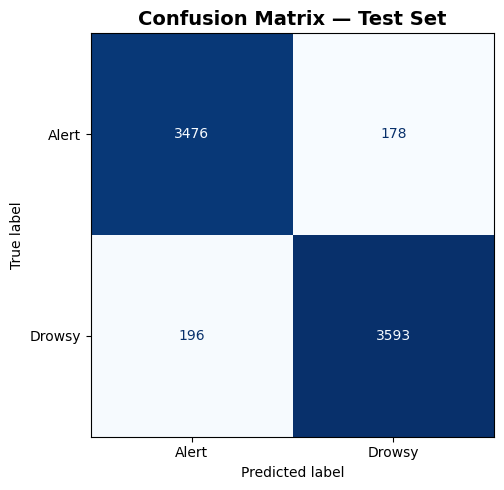

✅ Đã lưu Confusion Matrix vào Google Drive → /content/drive/MyDrive/Drowsiness_Project/confusion_matrix.png


In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
import torch

SAVE_DIR = Path('/content/drive/MyDrive/Drowsiness_Project')
BEST_PATH = SAVE_DIR / 'best_model.pth'

# 1. Nạp trọng số tốt nhất
print(f"🔄 Đang nạp model từ: {BEST_PATH}")
checkpoint = torch.load(str(BEST_PATH), map_location=device, weights_only=False)

if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'], strict=False)
elif isinstance(checkpoint, dict):
    model.load_state_dict(checkpoint, strict=False)
else:
    model.load_state_dict(checkpoint)

model.eval()
print("✅ Nạp trọng số Best Model thành công!")

# 2. Chạy suy luận trên test_loader
all_preds, all_labels = [], []

with torch.inference_mode():
    for step, (faces, eyes, mouths, labels, is_seqs) in enumerate(test_loader):
        labels  = labels.to(device, non_blocking=True)
        seq_idx = [i for i, s in enumerate(is_seqs) if s]
        img_idx = [i for i, s in enumerate(is_seqs) if not s]
        all_logits, all_lbls = [], []

        with torch.amp.autocast('cuda'):
            if seq_idx:
                f = torch.stack([faces[i]  for i in seq_idx]).to(device, non_blocking=True)
                e = torch.stack([eyes[i]   for i in seq_idx]).to(device, non_blocking=True)
                m = torch.stack([mouths[i] for i in seq_idx]).to(device, non_blocking=True)
                all_logits.append(model(f, e, m, is_sequence=True))
                all_lbls.append(labels[seq_idx])
                del f, e, m

            if img_idx:
                f = torch.stack([faces[i]  for i in img_idx]).to(device, non_blocking=True)
                e = torch.stack([eyes[i]   for i in img_idx]).to(device, non_blocking=True)
                m = torch.stack([mouths[i] for i in img_idx]).to(device, non_blocking=True)
                all_logits.append(model(f, e, m, is_sequence=False))
                all_lbls.append(labels[img_idx])
                del f, e, m

        logits = torch.cat(all_logits)
        lbls   = torch.cat(all_lbls)
        preds  = logits.argmax(1)

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(lbls.cpu().tolist())

        if (step + 1) % 100 == 0 or (step + 1) == len(test_loader):
            print(f'  Evaluating step {step+1}/{len(test_loader)}')

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# 3. In Classification Report
print('\n' + '=' * 50)
print('         CLASSIFICATION REPORT (TEST SET)         ')
print('=' * 50)
print(classification_report(
    all_labels, all_preds,
    target_names=['Alert', 'Drowsy'],
    digits=4
))

# 4. Vẽ và lưu Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Alert', 'Drowsy'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()

cm_path = SAVE_DIR / 'confusion_matrix.png'
plt.savefig(str(cm_path), dpi=150)
plt.show()
print(f'✅ Đã lưu Confusion Matrix vào Google Drive → {cm_path}')